<a href="https://colab.research.google.com/github/AdriBell01/context-sensitive-design-of-a-medical-device-/blob/main/syntheticdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# CELLA 1 — Setup e installazione dipendenze
# =====================================================================
!pip install librosa scikit-learn tensorflow tqdm matplotlib numpy pandas -q

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
print("TensorFlow version:", tf.__version__)
print("Setup completato.")

TensorFlow version: 2.20.0
Setup completato.


Generazione classe 0 (Normal)...


100%|██████████| 300/300 [00:47<00:00,  6.37it/s] 


Generazione classe 1 (Subclinical RHD)...


100%|██████████| 300/300 [00:05<00:00, 58.75it/s]


Generazione classe 2 (Advanced RHD)...


100%|██████████| 300/300 [00:07<00:00, 42.67it/s]



Dataset completo — shape: (900, 64, 256)
  Classe 0 (Normal): 300 campioni
  Classe 1 (Subclinical RHD): 300 campioni
  Classe 2 (Advanced RHD): 300 campioni


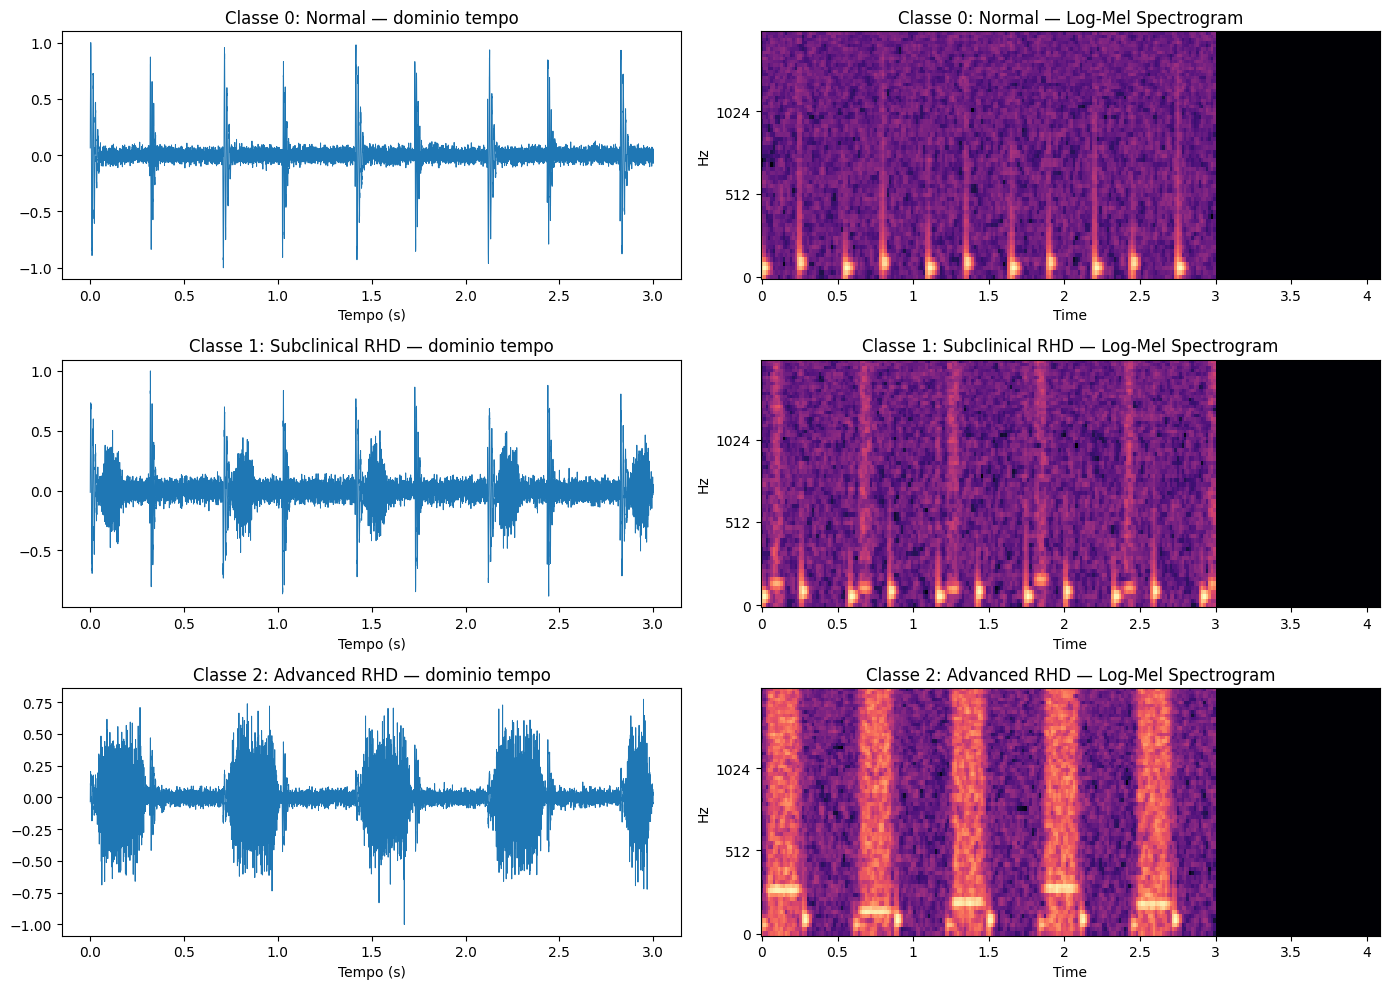


Train: 630 | Val: 135 | Test: 135
Input shape per il modello: (64, 256, 1)
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


In [ ]:
# =====================================================================
# DATASET SINTETICO COMPLETO —
# Genera PCG sintetici per le 3 classi:
#   Classe 0 — Normal
#   Classe 1 — Subclinical RHD (soffio lieve, intermittente)
#   Classe 2 — Advanced RHD   (soffio olosistolico severo)
# =====================================================================

SR         = 4000
N_MELS     = 64
N_FFT      = 256
HOP_LENGTH = 64
SG_MAXLEN  = 256

# ------------------------------------------------------------------
# Funzioni di generazione PCG per ogni classe
# ------------------------------------------------------------------

def generate_normal_pcg(sr=SR, duration=3.0, heart_rate=85,
                         noise_level=0.03, seed=None):
    """
    PCG normale: S1 e S2 ben definiti, nessun soffio.
    """
    if seed is not None:
        np.random.seed(seed)

    n  = int(sr * duration)
    t  = np.linspace(0, duration, n)
    sig = np.zeros(n)
    rr  = 60.0 / heart_rate

    for bt in np.arange(0, duration, rr):
        # S1 — chiusura mitrale/tricuspide (50-100 Hz)
        s1_c = bt
        s1_d = 0.09
        mask = (t >= s1_c) & (t < s1_c + s1_d)
        if mask.sum() > 0:
            env  = np.exp(-((t[mask] - s1_c) / (s1_d/3))**2)
            sig[mask] += 0.8 * env * np.sin(2*np.pi*80*t[mask])

        # S2 — chiusura aortica/polmonare (60-120 Hz)
        s2_c = bt + rr * 0.45
        s2_d = 0.07
        mask = (t >= s2_c) & (t < s2_c + s2_d)
        if mask.sum() > 0:
            env  = np.exp(-((t[mask] - s2_c) / (s2_d/3))**2)
            sig[mask] += 0.7 * env * np.sin(2*np.pi*110*t[mask])

    sig += noise_level * np.random.randn(n)
    return (sig / (np.max(np.abs(sig)) + 1e-8)).astype(np.float32)


def generate_subclinical_pcg(sr=SR, duration=3.0, heart_rate=90,
                              murmur_intensity=0.25, noise_level=0.04,
                              seed=None):
    """
    PCG subclinico: S1/S2 presenti, soffio sistolico lieve (20-200 Hz).
    Simula rigurgito mitralico lieve, caratteristico di RHD subclinica.
    """
    if seed is not None:
        np.random.seed(seed)

    n   = int(sr * duration)
    t   = np.linspace(0, duration, n)
    sig = np.zeros(n)
    rr  = 60.0 / heart_rate

    for bt in np.arange(0, duration, rr):
        # S1 — leggermente attenuato
        s1_c = bt
        s1_d = 0.09
        mask = (t >= s1_c) & (t < s1_c + s1_d)
        if mask.sum() > 0:
            env  = np.exp(-((t[mask] - s1_c) / (s1_d/3))**2)
            sig[mask] += 0.6 * env * np.sin(2*np.pi*80*t[mask])

        # Soffio sistolico lieve (occupa ~50% della sistole)
        mur_s = s1_c + 0.05
        mur_e = s1_c + rr * 0.25   # solo prima metà sistole
        mask  = (t >= mur_s) & (t < mur_e)
        if mask.sum() > 0:
            nm    = mask.sum()
            ramp  = max(1, int(0.03 * sr))
            env   = np.ones(nm)
            if nm > 2 * ramp:
                env[:ramp]  = np.linspace(0, 1, ramp)
                env[-ramp:] = np.linspace(1, 0, ramp)
            f_mur = np.random.uniform(100, 200)
            sig[mask] += murmur_intensity * env * (
                0.6 * np.sin(2*np.pi*f_mur*t[mask]) +
                0.4 * np.random.randn(nm)
            )

        # S2 — preservato
        s2_c = bt + rr * 0.45
        s2_d = 0.07
        mask = (t >= s2_c) & (t < s2_c + s2_d)
        if mask.sum() > 0:
            env  = np.exp(-((t[mask] - s2_c) / (s2_d/3))**2)
            sig[mask] += 0.7 * env * np.sin(2*np.pi*110*t[mask])

    sig += noise_level * np.random.randn(n)
    return (sig / (np.max(np.abs(sig)) + 1e-8)).astype(np.float32)


def generate_advanced_pcg(sr=SR, duration=3.0, heart_rate=95,
                           murmur_intensity=0.65, noise_level=0.05,
                           seed=None):
    """
    PCG avanzato: soffio olosistolico severo (20-600 Hz),
    S1 molto attenuato, S2 preservato.
    """
    if seed is not None:
        np.random.seed(seed)

    n   = int(sr * duration)
    t   = np.linspace(0, duration, n)
    sig = np.zeros(n)
    rr  = 60.0 / heart_rate

    for bt in np.arange(0, duration, rr):
        # S1 — molto attenuato
        s1_c = bt
        s1_d = 0.09
        mask = (t >= s1_c) & (t < s1_c + s1_d)
        if mask.sum() > 0:
            env  = np.exp(-((t[mask] - s1_c) / (s1_d/3))**2)
            sig[mask] += 0.3 * env * np.sin(2*np.pi*80*t[mask])

        # Soffio olosistolico (occupa TUTTA la sistole)
        mur_s = s1_c + 0.02
        mur_e = s1_c + rr * 0.43
        mask  = (t >= mur_s) & (t < mur_e)
        if mask.sum() > 0:
            nm    = mask.sum()
            ramp  = max(1, int(0.04 * sr))
            env   = np.ones(nm)
            if nm > 2 * ramp:
                env[:ramp]  = np.linspace(0, 1, ramp)
                env[-ramp:] = np.linspace(1, 0, ramp)
            f_mur = np.random.uniform(150, 400)
            sig[mask] += murmur_intensity * env * (
                0.5 * np.sin(2*np.pi*f_mur*t[mask]) +
                0.5 * np.random.randn(nm)
            )

        # S2 — preservato
        s2_c = bt + rr * 0.45
        s2_d = 0.07
        mask = (t >= s2_c) & (t < s2_c + s2_d)
        if mask.sum() > 0:
            env  = np.exp(-((t[mask] - s2_c) / (s2_d/3))**2)
            sig[mask] += 0.7 * env * np.sin(2*np.pi*110*t[mask])

    sig += noise_level * np.random.randn(n)
    return (sig / (np.max(np.abs(sig)) + 1e-8)).astype(np.float32)


# ------------------------------------------------------------------
# Conversione PCG → Log-Mel Spectrogram
# ------------------------------------------------------------------

def pcg_to_melspec(signal, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
                   hop_length=HOP_LENGTH, sg_maxlen=SG_MAXLEN):
    S    = librosa.feature.melspectrogram(
               y=signal, sr=sr, n_mels=n_mels,
               n_fft=n_fft, hop_length=hop_length)
    S_dB = librosa.power_to_db(S, ref=np.max)
    if S_dB.shape[1] < sg_maxlen:
        pad  = sg_maxlen - S_dB.shape[1]
        S_dB = np.pad(S_dB, ((0,0),(0,pad)),
                      mode='constant', constant_values=S_dB.min())
    else:
        S_dB = S_dB[:, :sg_maxlen]
    return S_dB.astype(np.float32)


# ------------------------------------------------------------------
# Generazione del dataset
# ------------------------------------------------------------------

N_PER_CLASS = 300   # campioni per classe — aumenta se vuoi più dati

generators = [
    (generate_normal_pcg,     {'noise_level': 0.03},                          0),
    (generate_subclinical_pcg,{'murmur_intensity': 0.25, 'noise_level': 0.04}, 1),
    (generate_advanced_pcg,   {'murmur_intensity': 0.65, 'noise_level': 0.05}, 2),
]

class_names = ['Normal', 'Subclinical RHD', 'Advanced RHD']
X_list, y_list = [], []

for gen_fn, kwargs, label in generators:
    print(f"Generazione classe {label} ({class_names[label]})...")
    for i in tqdm(range(N_PER_CLASS)):
        hr  = np.random.randint(75, 110)   # variabilità HR pediatrica
        sig = gen_fn(sr=SR, duration=3.0, heart_rate=hr, seed=i, **kwargs)
        sg  = pcg_to_melspec(sig)
        X_list.append(sg)
        y_list.append(label)

X_all = np.array(X_list, dtype=np.float32)
y_all = np.array(y_list, dtype=np.int32)

print(f"\nDataset completo — shape: {X_all.shape}")
for i, name in enumerate(class_names):
    print(f"  Classe {i} ({name}): {np.sum(y_all==i)} campioni")

# ------------------------------------------------------------------
# Visualizzazione esempio per ogni classe
# ------------------------------------------------------------------

fig, axs = plt.subplots(3, 2, figsize=(14, 10))
for cls in range(3):
    idx = np.where(y_all == cls)[0][0]
    # Ricostruisci il segnale per il plot temporale
    hr  = 85
    fns = [generate_normal_pcg, generate_subclinical_pcg, generate_advanced_pcg]
    kws = [{}, {'murmur_intensity': 0.25}, {'murmur_intensity': 0.65}]
    sig = fns[cls](sr=SR, duration=3.0, heart_rate=hr, seed=0, **kws[cls])

    axs[cls, 0].plot(np.linspace(0, 3, len(sig)), sig, linewidth=0.7)
    axs[cls, 0].set_title(f'Classe {cls}: {class_names[cls]} — dominio tempo')
    axs[cls, 0].set_xlabel('Tempo (s)')

    librosa.display.specshow(
        X_all[idx], sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', ax=axs[cls, 1]
    )
    axs[cls, 1].set_title(f'Classe {cls}: {class_names[cls]} — Log-Mel Spectrogram')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Preprocessing finale: normalizzazione + dimensione canale + split
# ------------------------------------------------------------------

X_all = X_all[..., np.newaxis]   # (N, n_mels, sg_maxlen, 1)

X_min, X_max = X_all.min(), X_all.max()
X_all = 2 * (X_all - X_min) / (X_max - X_min + 1e-8) - 1

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

cw = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Input shape per il modello: {X_train.shape[1:]}")
print(f"Class weights: {class_weights}")

SQI segnale grezzo:      0.424
SQI segnale processato:  0.745
Qualità accettabile:     ✅ SI


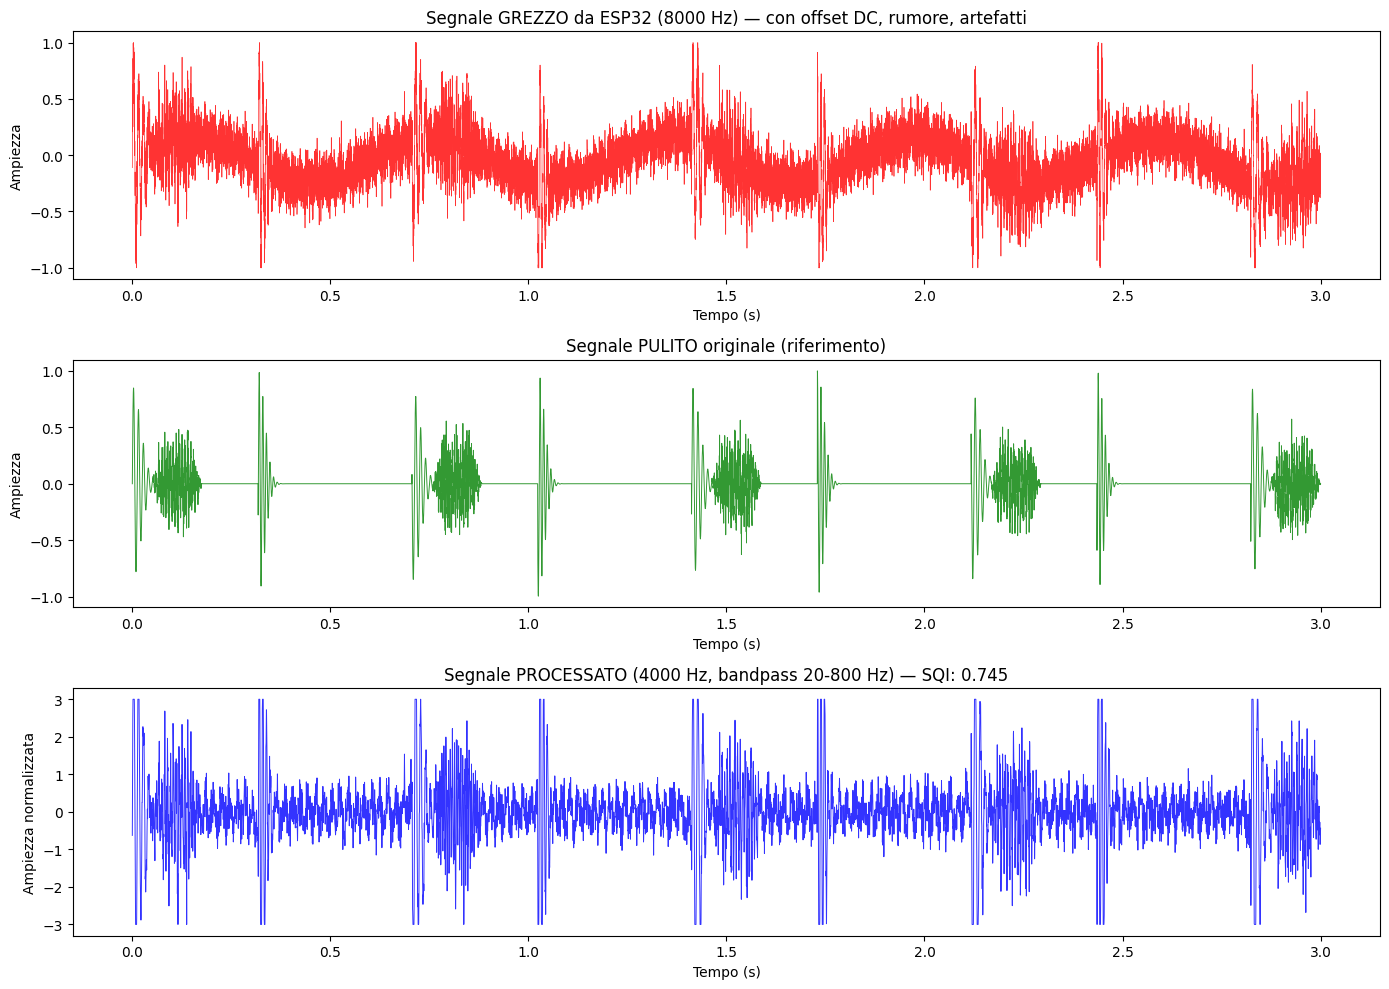


Input pronto per il modello — shape: (1, 64, 256, 1)
SQI: 0.745
Puoi ora chiamare: model.predict(sg_input)


In [ ]:
# =====================================================================
# CELLA PREPROCESSING
# Simula un segnale grezzo come uscirebbe dall'ESP32 e applica
# la pipeline completa di preprocessing.
# Questo è il codice che userai in produzione con i WAV reali.
# =====================================================================

from scipy.signal import butter, sosfiltfilt, decimate
from scipy.stats import zscore

# ------------------------------------------------------------------
# STEP 1 — Simulazione segnale grezzo ESP32
# ------------------------------------------------------------------
# Il segnale reale dall'ESP32 avrà:
#   - Sampling rate 8000 Hz (poi decimiamo a 4000)
#   - Offset DC dal microfono MEMS
#   - Rumore ambientale pesante (voci, rumori di fondo)
#   - Artefatti da movimento (bassa frequenza, <20 Hz)
#   - Possibile saturazione/clipping

def simulate_raw_esp32_signal(clean_signal, sr_clean=4000, sr_raw=8000):
    """
    Prende un segnale PCG pulito a 4000 Hz e simula
    come sarebbe il segnale grezzo uscente dall'ESP32 a 8000 Hz.
    """
    # Upsample a 8000 Hz (interpola)
    ratio    = sr_raw // sr_clean
    upsampled = np.repeat(clean_signal, ratio)

    n = len(upsampled)
    t = np.linspace(0, len(clean_signal)/sr_clean, n)

    # Offset DC (deriva del microfono MEMS)
    dc_offset = np.random.uniform(-0.15, 0.15)

    # Rumore ambientale broadband (voci, ambiente)
    ambient_noise = np.random.randn(n) * np.random.uniform(0.05, 0.15)

    # Artefatto da movimento (bassa frequenza <5 Hz)
    movement = 0.2 * np.sin(2 * np.pi * np.random.uniform(0.5, 3) * t)

    # Interferenza elettrica (50 Hz — rete elettrica)
    powerline = np.random.uniform(0.02, 0.08) * np.sin(2 * np.pi * 50 * t)

    # Somma tutto
    raw = upsampled + dc_offset + ambient_noise + movement + powerline

    # Simula clipping (ADC a 16 bit, range [-1, 1])
    raw = np.clip(raw, -1.0, 1.0)

    return raw.astype(np.float32), sr_raw


# ------------------------------------------------------------------
# STEP 2 — Pipeline di preprocessing completa
# ------------------------------------------------------------------

def preprocess_pcg(raw_signal, sr_raw=8000, sr_target=4000,
                   f_low=20, f_high=800, filter_order=6):
    """
    Pipeline completa di preprocessing:
      1. Decimazione da sr_raw a sr_target
      2. Rimozione offset DC
      3. Filtro bandpass Butterworth (f_low - f_high Hz)
      4. Normalizzazione z-score
      5. Rimozione artefatti da clipping
    Restituisce il segnale processato a sr_target Hz.
    """

    # --- 1. Decimazione ---
    # Dimezza da 8000 Hz a 4000 Hz con anti-aliasing integrato
    decimation_factor = sr_raw // sr_target
    signal = decimate(raw_signal, decimation_factor, ftype='fir', zero_phase=True)
    signal = signal.astype(np.float32)

    # --- 2. Rimozione offset DC ---
    # Sottrae la media (componente continua dal microfono)
    signal = signal - np.mean(signal)

    # --- 3. Filtro bandpass Butterworth zero-phase ---
    # Isola la banda cardiaca 20-800 Hz
    # Zero-phase (sosfiltfilt) per non distorcere la posizione
    # temporale di S1 e S2 — critico per la segmentazione
    nyq  = sr_target / 2.0
    low  = f_low  / nyq
    high = f_high / nyq
    sos  = butter(filter_order, [low, high], btype='band', output='sos')
    signal = sosfiltfilt(sos, signal)

    # --- 4. Normalizzazione z-score ---
    # Media 0, deviazione standard 1
    # Rende il modello invariante alle differenze di guadagno
    # tra sessioni di acquisizione diverse
    std = np.std(signal)
    if std > 1e-8:
        signal = (signal - np.mean(signal)) / std

    # --- 5. Gestione clipping residuo ---
    # Taglia valori estremi (>3 std) che indicano artefatti
    signal = np.clip(signal, -3.0, 3.0)

    return signal.astype(np.float32)


# ------------------------------------------------------------------
# STEP 3 — Signal Quality Index (SQI)
# ------------------------------------------------------------------

def compute_sqi(signal, sr=4000, f_low=20, f_high=800):
    """
    Calcola un indice di qualità del segnale (0-1).
    Combina 3 metriche:
      - SNR stimato (potenza banda cardiaca / potenza fuori banda)
      - Kurtosis (segnali cardiaci hanno kurtosis > 3)
      - Stabilità dell'ampiezza (segnali buoni hanno varianza stabile)
    Soglia consigliata: SQI > 0.4 per accettare la registrazione.
    """
    from scipy.stats import kurtosis
    from scipy.signal import welch

    # SNR stimato tramite Power Spectral Density
    freqs, psd = welch(signal, fs=sr, nperseg=256)
    cardiac_mask  = (freqs >= f_low)  & (freqs <= f_high)
    noise_mask    = (freqs > f_high)

    cardiac_power = psd[cardiac_mask].mean() + 1e-10
    noise_power   = psd[noise_mask].mean()   + 1e-10
    snr_score     = np.clip(cardiac_power / noise_power / 10, 0, 1)

    # Kurtosis — i suoni cardiaci hanno picchi impulsivi (kurtosis > 3)
    kurt          = kurtosis(signal)
    kurt_score    = np.clip((kurt - 1) / 10, 0, 1)

    # Stabilità — divide il segnale in finestre e controlla
    # che l'energia non vari troppo (artefatti da movimento)
    window_size   = sr // 2   # finestre da 0.5 secondi
    n_windows     = len(signal) // window_size
    if n_windows > 1:
        energies      = [np.var(signal[i*window_size:(i+1)*window_size])
                         for i in range(n_windows)]
        stability     = 1 - np.std(energies) / (np.mean(energies) + 1e-8)
        stability     = np.clip(stability, 0, 1)
    else:
        stability     = 0.5

    # SQI finale: media pesata delle 3 metriche
    sqi = 0.5 * snr_score + 0.3 * kurt_score + 0.2 * stability
    return float(np.clip(sqi, 0, 1))

SQI_THRESHOLD = 0.4  # soglia minima per accettare la registrazione


# ------------------------------------------------------------------
# STEP 4 — Test visivo della pipeline su un segnale di esempio
# ------------------------------------------------------------------

# Prendi un segnale pulito (subclinical RHD come esempio)
clean = generate_subclinical_pcg(sr=SR, duration=3.0,
                                  heart_rate=85,
                                  murmur_intensity=0.25,
                                  noise_level=0.0,   # niente rumore
                                  seed=42)

# Simula il segnale grezzo ESP32
raw, sr_raw = simulate_raw_esp32_signal(clean, sr_clean=SR, sr_raw=8000)

# Applica preprocessing
processed = preprocess_pcg(raw, sr_raw=sr_raw, sr_target=SR)

# Calcola SQI
sqi_raw       = compute_sqi(raw[::2])   # downsampled per confronto
sqi_processed = compute_sqi(processed)
print(f"SQI segnale grezzo:      {sqi_raw:.3f}")
print(f"SQI segnale processato:  {sqi_processed:.3f}")
print(f"Qualità accettabile:     {'✅ SI' if sqi_processed >= SQI_THRESHOLD else '❌ NO — ripetere acquisizione'}")

# Plot confronto
t_raw  = np.linspace(0, len(raw)/sr_raw, len(raw))
t_proc = np.linspace(0, len(processed)/SR, len(processed))

fig, axs = plt.subplots(3, 1, figsize=(14, 10))

axs[0].plot(t_raw, raw, linewidth=0.5, color='red', alpha=0.8)
axs[0].set_title('Segnale GREZZO da ESP32 (8000 Hz) — con offset DC, rumore, artefatti')
axs[0].set_xlabel('Tempo (s)')
axs[0].set_ylabel('Ampiezza')

axs[1].plot(t_proc, clean, linewidth=0.7, color='green', alpha=0.8)
axs[1].set_title('Segnale PULITO originale (riferimento)')
axs[1].set_xlabel('Tempo (s)')
axs[1].set_ylabel('Ampiezza')

axs[2].plot(t_proc, processed, linewidth=0.7, color='blue', alpha=0.8)
axs[2].set_title(f'Segnale PROCESSATO (4000 Hz, bandpass 20-800 Hz) — SQI: {sqi_processed:.3f}')
axs[2].set_xlabel('Tempo (s)')
axs[2].set_ylabel('Ampiezza normalizzata')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# STEP 5 — Funzione end-to-end: WAV grezzo → Mel-spectrogram
# ------------------------------------------------------------------
# Questa è la funzione che userai in produzione quando arriva
# un file WAV reale dall'ESP32

def wav_to_input(wav_path=None, raw_signal=None, sr_raw=8000,
                 sr_target=4000, sqi_threshold=SQI_THRESHOLD):
    """
    Funzione end-to-end per uso in produzione.
    Accetta un path WAV oppure direttamente un array numpy.
    Restituisce:
      - il Mel-spectrogram pronto per il modello  (o None se SQI < soglia)
      - il valore SQI
      - il segnale processato (per debug/visualizzazione)
    """
    import soundfile as sf

    # Carica WAV se fornito come path
    if wav_path is not None:
        raw_signal, sr_raw = sf.read(wav_path)
        if raw_signal.ndim > 1:
            raw_signal = raw_signal[:, 0]   # prendi solo canale sinistro
        raw_signal = raw_signal.astype(np.float32)

    # Preprocessing
    processed = preprocess_pcg(raw_signal, sr_raw=sr_raw, sr_target=sr_target)

    # Controllo qualità
    sqi = compute_sqi(processed, sr=sr_target)
    if sqi < sqi_threshold:
        print(f"⚠️  SQI = {sqi:.3f} < {sqi_threshold} — qualità insufficiente, ripetere acquisizione")
        return None, sqi, processed

    # Conversione in Mel-spectrogram
    sg = pcg_to_melspec(processed, sr=sr_target)

    # Aggiungi dimensioni per il modello: (1, n_mels, sg_maxlen, 1)
    sg_input = sg[np.newaxis, ..., np.newaxis]

    # Normalizzazione nello stesso range usato durante il training
    sg_input = 2 * (sg_input - X_min) / (X_max - X_min + 1e-8) - 1

    return sg_input, sqi, processed


# Test della funzione end-to-end su segnale simulato
sg_input, sqi, proc = wav_to_input(raw_signal=raw, sr_raw=8000)
if sg_input is not None:
    print(f"\nInput pronto per il modello — shape: {sg_input.shape}")
    print(f"SQI: {sqi:.3f}")
    print("Puoi ora chiamare: model.predict(sg_input)")

In [ ]:
# =====================================================================
# CELLA 6 — Modello CNN + LSTM
# =====================================================================

def build_cnn_lstm(input_shape, n_classes=3, lstm_units=64, dropout=0.3):
    """
    Architettura:
      - CNN leggera (ispirata a MobileNet con depthwise separable conv)
        estrae feature spaziali dallo spettrogramma
      - Reshape per passare sequenza temporale all'LSTM
      - LSTM cattura dipendenze temporali tra frame successivi
      - Dense softmax per classificazione 3 classi
    """
    inp = layers.Input(shape=input_shape)  # (n_mels, sg_maxlen, 1)

    # --- Blocco CNN ---
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout)(x)

    x = layers.DepthwiseConv2D((3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout)(x)

    x = layers.DepthwiseConv2D((3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (1, 1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)  # pool solo su asse mel, non tempo
    x = layers.Dropout(dropout)(x)

    # --- Reshape per LSTM ---
    # Dopo CNN: (batch, n_mels_reduced, time_steps, channels)
    # Vogliamo: (batch, time_steps, features) per LSTM
    cnn_shape = x.shape  # (None, h, w, c)
    x = layers.Permute((2, 1, 3))(x)                     # (None, w, h, c)
    x = layers.Reshape((cnn_shape[2], cnn_shape[1] * cnn_shape[3]))(x)

    # --- Blocco LSTM ---
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units // 2)(x)
    x = layers.Dropout(dropout)(x)

    # --- Output ---
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=out, name='CNN_LSTM_RHD')
    return model


input_shape = X_train.shape[1:]  # (n_mels, sg_maxlen, 1)
model = build_cnn_lstm(input_shape, n_classes=3)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_acc')]
)

Model: "CNN_LSTM_RHD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 256, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 256, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 32, 128, 32)    │           320 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 128, 64)    │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 16, 64, 64)     │           640 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 64, 128)    │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 64, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 64, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 64, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 64, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64, 64)         │       278,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,115 (1.17 MB)

 Trainable params: 305,667 (1.17 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# =====================================================================
# CELLA 7 — Training
# =====================================================================

EPOCHS     = 50
BATCH_SIZE = 32

cb_list = [
    # Salva il modello migliore in base alla val_loss
    callbacks.ModelCheckpoint(
        '/content/best_model.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
    # Riduce il learning rate se val_loss non migliora per 5 epoche
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    # Early stopping se val_loss non migliora per 12 epoche
    callbacks.EarlyStopping(
        monitor='val_loss', patience=12,
        restore_best_weights=True, verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cb_list
)
print("Training completato.")

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5444 - loss: 0.9285 - top2_acc: 0.8482
Epoch 1: val_loss improved from None to 1.12141, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.6381 - loss: 0.8306 - top2_acc: 0.9063 - val_accuracy: 0.3333 - val_loss: 1.1214 - val_top2_acc: 0.6667 - learning_rate: 0.0010
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7652 - loss: 0.6606 - top2_acc: 0.9430
Epoch 2: val_loss did not improve from 1.12141
20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.7540 - loss: 0.6195 - top2_acc: 0.9651 - val_accuracy: 0.3333 - val_loss: 1.2539 - val_top2_acc: 0.6667 - learning_rate: 0.0010
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8415 - loss: 0.4307 - top2_acc: 0.9804
Epoch 3: val_loss did not improve from 1.12141
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8905 - loss: 0.3338 - top2_acc: 0

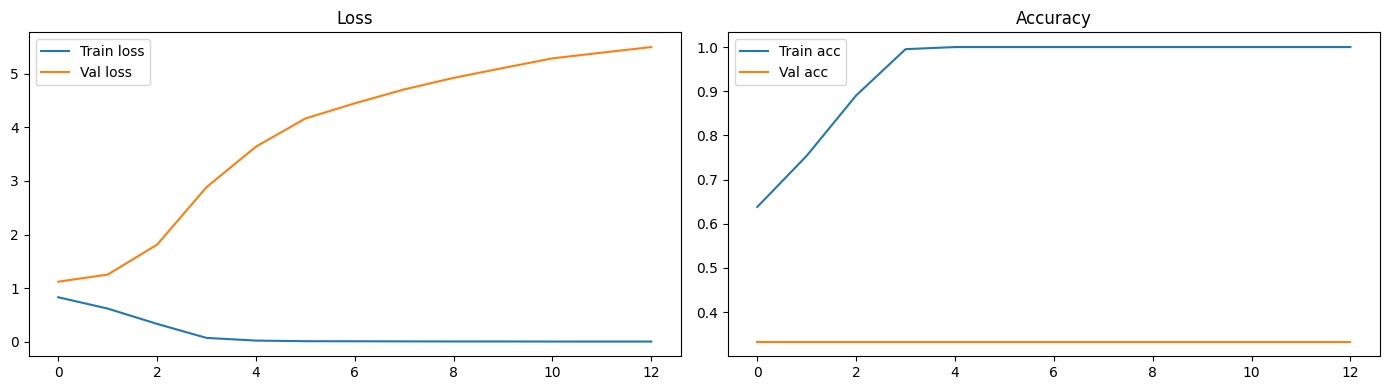

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step

Classification Report:
                        precision    recall  f1-score   support

                Normal       0.00      0.00      0.00        45
Murmur/Subclinical RHD       0.00      0.00      0.00        45
          RHD Advanced       0.33      1.00      0.50        45

              accuracy                           0.33       135
             macro avg       0.11      0.33      0.17       135
          weighted avg       0.11      0.33      0.17       135



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


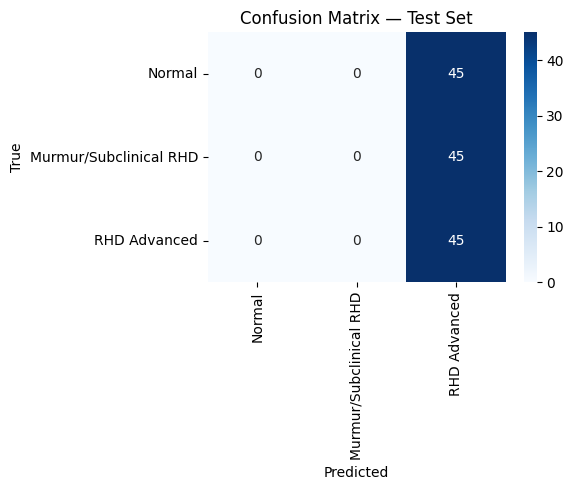


Sensitivity (macro):  0.333
Specificity per classe: {'Normal': '1.000', 'Murmur/Subclinical RHD': '1.000', 'RHD Advanced': '0.000'}
Must-have target: Sensitivity >= 0.85 | ❌ NON RAGGIUNTO


In [ ]:
# =====================================================================
# CELLA 8 — Valutazione e grafici
# =====================================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- Curve di loss e accuracy ---
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(history.history['loss'],     label='Train loss')
axs[0].plot(history.history['val_loss'], label='Val loss')
axs[0].set_title('Loss')
axs[0].legend()

axs[1].plot(history.history['accuracy'],     label='Train acc')
axs[1].plot(history.history['val_accuracy'], label='Val acc')
axs[1].set_title('Accuracy')
axs[1].legend()
plt.tight_layout()
plt.show()

# --- Valutazione sul test set ---
y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)

class_names = ['Normal', 'Murmur/Subclinical RHD', 'RHD Advanced']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

# --- Metriche chiave per il report ---
from sklearn.metrics import recall_score, precision_score, f1_score
sensitivity = recall_score(y_test, y_pred, average='macro')
specificity_per_class = []
for i in range(len(class_names)):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    specificity_per_class.append(tn / (tn + fp + 1e-8))

print(f"\nSensitivity (macro):  {sensitivity:.3f}")
print(f"Specificity per classe: {dict(zip(class_names, [f'{s:.3f}' for s in specificity_per_class]))}")
print(f"Must-have target: Sensitivity >= 0.85 | {'✅ PASS' if sensitivity >= 0.85 else '❌ NON RAGGIUNTO'}")

In [ ]:
# =====================================================================
# CELLA 9 — Conversione TFLite (Edge AI per Android)
# =====================================================================

# Carica il miglior modello salvato
best_model = tf.keras.models.load_model('/content/best_model.keras')

# Converti in TFLite con quantizzazione INT8
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantizzazione post-training

# Dataset rappresentativo per calibrazione INT8
def representative_dataset():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

tflite_path = '/content/rhd_model_int8.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_fp32   = os.path.getsize('/content/best_model.keras') / 1e6
size_tflite = os.path.getsize(tflite_path) / 1e6
print(f"Modello Keras (.keras): {size_fp32:.2f} MB")
print(f"Modello TFLite INT8:    {size_tflite:.2f} MB")
print(f"Riduzione dimensione:   {(1 - size_tflite/size_fp32)*100:.1f}%")
print(f"\nFile TFLite salvato in: {tflite_path}")
print("Pronto per il deployment su Android via TensorFlow Lite.")

Saved artifact at '/tmp/tmpyfps7lrv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 256, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135531335367952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531335367184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531329930448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531329930640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531335367376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531335368528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531329929680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531329930064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531329931984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531329931216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135531329930256:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


ConverterError: <unknown>:0: error: loc(callsite(fused["TensorListReserve:", "CNN_LSTM_RHD_1/lstm_1/TensorArrayV2_1@__inference_function_13469"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_13608"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_13608"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: error: loc(callsite(fused["TensorListReserve:", "CNN_LSTM_RHD_1/lstm_1/TensorArrayV2_1@__inference_function_13469"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_13608"] at fused["StatefulPartitionedCa